In [1]:
import pandas as pd
import numpy as np
import joblib, json, pathlib
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 150)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

ENCDM = pd.read_spss('../Data/Raw/ENCDM.sav')
RGPH = pd.read_spss('../Data/Raw/RGPH.sav')

ENCDM = ENCDM[ENCDM.columns[:26]]

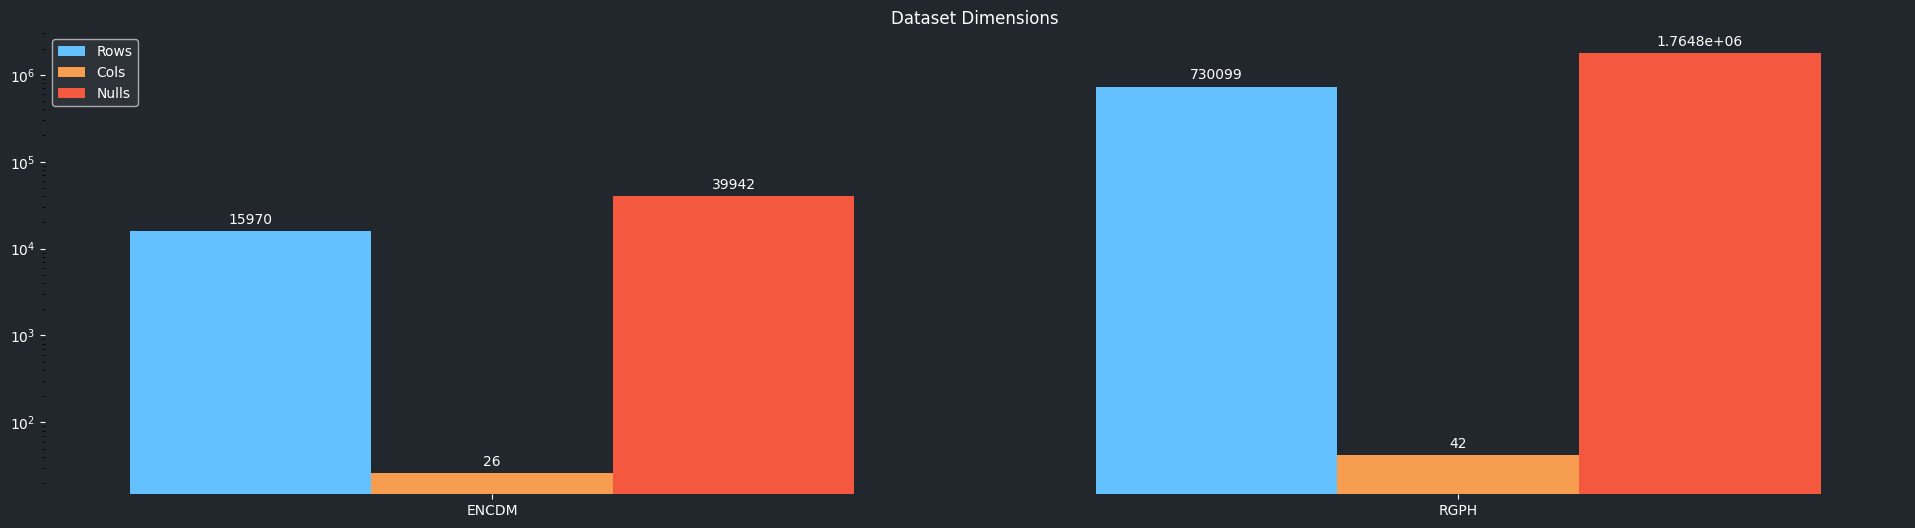

In [2]:
names = ['ENCDM', 'RGPH']
data = {'Rows': [len(ENCDM), len(RGPH)], 'Cols': [len(ENCDM.columns), len(RGPH.columns)], 'Nulls': [ENCDM.isnull().sum().sum(), RGPH.isnull().sum().sum()]}

x = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize = (24, 6), facecolor = '#22272E')
ax.set_facecolor('#22272E')

for spine in plt.gca().spines.values() : spine.set_visible(False)

cols = ax.bar(x - width, data['Rows'], width, label = 'Rows', color = '#62C1FE')
rows = ax.bar(x, data['Cols'], width, label = 'Cols', color = '#F69D50')
nulls = ax.bar(x + width, data['Nulls'], width, label = 'Nulls', color = '#F4583E')

ax.set_yscale('log')
ax.set_xticks(x, names, color = 'white')
ax.tick_params(colors = 'white')
ax.set_title('Dataset Dimensions', color = 'white')
ax.legend(facecolor = '#32373E', labelcolor = 'white')

ax.bar_label(cols, color = 'white', padding = 3)
ax.bar_label(rows, color = 'white', padding = 3)
ax.bar_label(nulls, color = 'white', padding = 3)

plt.show()

In [3]:
display(ENCDM.head(3), pd.DataFrame(ENCDM.dtypes).T)

,N_ménage,coef_ménage,coef_indiv,Milieu,Région_12,Taille_ménage,Taille_agregée,Pauvre,Vulnérable,Quintiles,Deciles,Quintileurbain,Decileurbain,Quintilerural,Decilerural,Sexe_CM,Age_CM,Age_quin_CM,Lieunaissance_CM,Etat_matrimonial_CM,Niveau_scolaire_agreg_CM,Diplôme_agregé_CM,Type_activité_dominante_CM,Profession_agreg_CM,Secteur_activité_agreg_CM,Situation_profession_agreg_CM
0,1.0,165.0,560.0,Urbain,Dakhla-Oued Ed Dahab,2,2 personnes,Non pauvre,0.0,"20394,93+","29062,21+","25063,81+","36561,71+",NaN,NaN,Masculin,26,25-29,1.0,Marié,Primaire,Niveau moyen,Actif occupé,"Manœuvres non agricoles, manutentionnaires et travailleurs des petits métiers",Commerce,Indépendant
1,2.0,165.0,676.0,Urbain,Dakhla-Oued Ed Dahab,3,3 personnes,Non pauvre,0.0,"13639,81 - 20394,92","13639,81 - 16332,33","12240,49 - 16693,25","14270,05 - 16693,25",NaN,NaN,Masculin,36,35-39,1.0,Marié,Secondaire qualifiant,Niveau moyen,Actif occupé,"Exploitants et ouvriers agricoles (y compris pêche, chasse et forêt)","Agriculture, forêt et pêhe",Salarié
2,3.0,165.0,677.0,Urbain,Dakhla-Oued Ed Dahab,3,3 personnes,Non pauvre,0.0,"13639,81 - 20394,92","16332,34 - 20394,92","16693,26 - 25063,80","19980,68 - 25063,80",NaN,NaN,Masculin,38,35-39,2.0,Marié,Primaire,Sans diplôme,Actif occupé,Artisans et ouvriers qualifies et conducteurs d'installations et de machines et ouvriers de l'assemblage,Batiment et travaux publics,Indépendant


,N_ménage,coef_ménage,coef_indiv,Milieu,Région_12,Taille_ménage,Taille_agregée,Pauvre,Vulnérable,Quintiles,Deciles,Quintileurbain,Decileurbain,Quintilerural,Decilerural,Sexe_CM,Age_CM,Age_quin_CM,Lieunaissance_CM,Etat_matrimonial_CM,Niveau_scolaire_agreg_CM,Diplôme_agregé_CM,Type_activité_dominante_CM,Profession_agreg_CM,Secteur_activité_agreg_CM,Situation_profession_agreg_CM
0,float64,float64,float64,category,category,object,category,category,category,category,category,category,category,category,category,category,object,category,float64,category,category,category,category,category,category,category


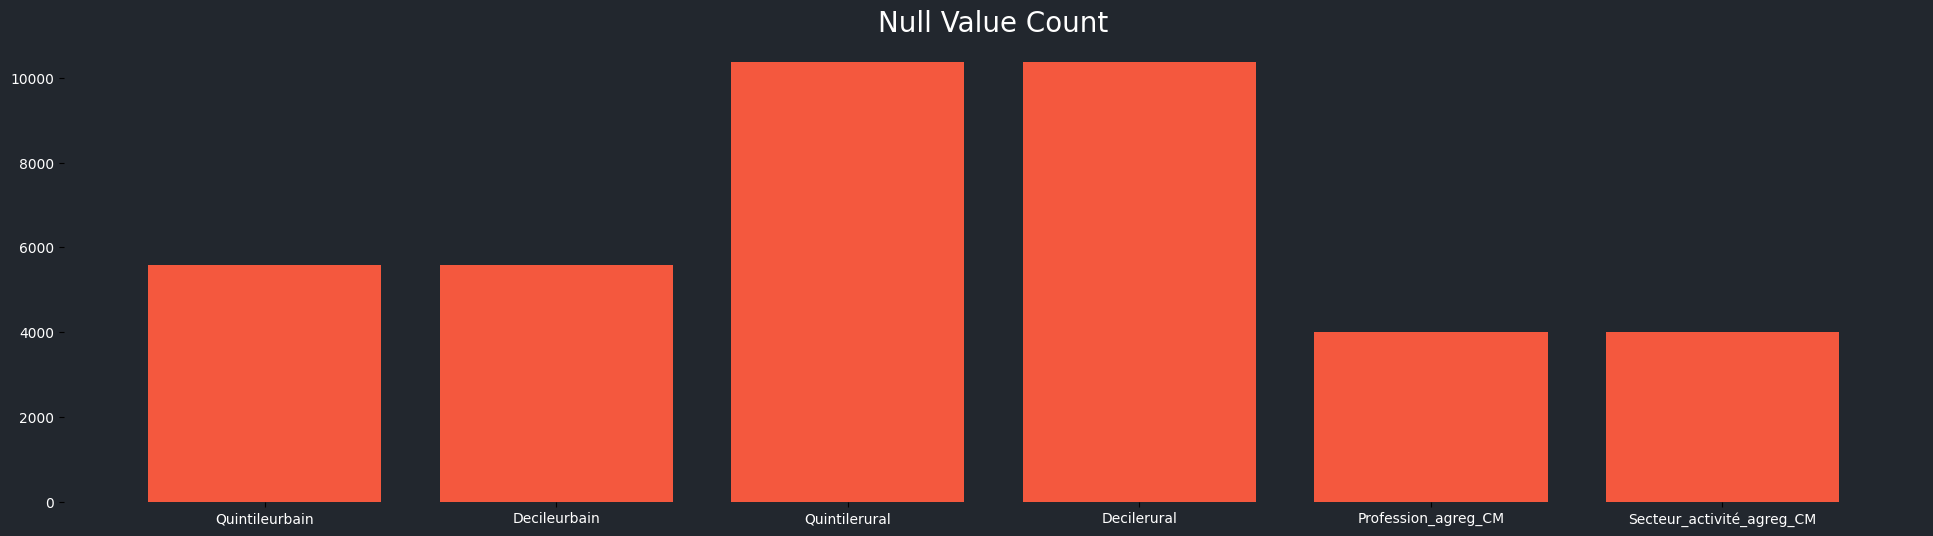

In [4]:
plt.figure(figsize = (24, 6), facecolor = '#22272E')
plt.gca().set_facecolor('#22272E')

for spine in plt.gca().spines.values() : spine.set_visible(False)

nulls = ENCDM.isnull().sum()
nulls = nulls[nulls > 0]

plt.bar(nulls.index, nulls, color = '#F4583E')
plt.title('Null Value Count', color = 'white', fontsize = 20)
plt.xticks(color = 'white')
plt.yticks(color = 'white')
plt.show()

In [5]:
for column in ['Taille_ménage', 'Age_CM'] : ENCDM[column] = ENCDM[column].astype('float64')
display(pd.DataFrame(ENCDM.dtypes).T)

MapENCDM = {column: {i[1] : (i[0] if str(i[1]).lower() != 'nan' else None) for i in enumerate(ENCDM[column].unique())} for column in ENCDM.columns if ENCDM[column].dtype == 'category'}

if not pathlib.Path('../Assets/Maps/MapENCDM.json').exists() :
    with open('../Assets/Maps/MapENCDM.json', 'w', encoding = 'utf-8') as file :
        json.dump({column : dict(sorted(map.items(), key = lambda item: len(str(item[0])))) for column, map in MapENCDM.items()}, file, indent = 4, ensure_ascii = False)

Encoded = pd.DataFrame({column: ENCDM[column].map(MapENCDM[column]) for column in MapENCDM.keys()}, dtype = 'category')
CleanENCDM = pd.DataFrame({column : (ENCDM[column] if column not in Encoded.columns else Encoded[column]) for column in ENCDM.columns})

TypesENCDM = {column : str(CleanENCDM[column].dtype) for column in CleanENCDM.columns}

if not pathlib.Path('../Assets/Types/TypesENCDM.json').exists() :
    with open('../Assets/Types/TypesENCDM.json', 'w', encoding = 'utf-8') as file :
        json.dump(TypesENCDM, file, indent = 4, ensure_ascii = False)

for column in CleanENCDM.columns : CleanENCDM[column] = CleanENCDM[column].astype('float64')

display(CleanENCDM, pd.DataFrame({i[0] : [i[1]] for i in TypesENCDM.items()}))

,N_ménage,coef_ménage,coef_indiv,Milieu,Région_12,Taille_ménage,Taille_agregée,Pauvre,Vulnérable,Quintiles,Deciles,Quintileurbain,Decileurbain,Quintilerural,Decilerural,Sexe_CM,Age_CM,Age_quin_CM,Lieunaissance_CM,Etat_matrimonial_CM,Niveau_scolaire_agreg_CM,Diplôme_agregé_CM,Type_activité_dominante_CM,Profession_agreg_CM,Secteur_activité_agreg_CM,Situation_profession_agreg_CM
0,float64,float64,float64,category,category,float64,category,category,category,category,category,category,category,category,category,category,float64,category,float64,category,category,category,category,category,category,category


,N_ménage,coef_ménage,coef_indiv,Milieu,Région_12,Taille_ménage,Taille_agregée,Pauvre,Vulnérable,Quintiles,Deciles,Quintileurbain,Decileurbain,Quintilerural,Decilerural,Sexe_CM,Age_CM,Age_quin_CM,Lieunaissance_CM,Etat_matrimonial_CM,Niveau_scolaire_agreg_CM,Diplôme_agregé_CM,Type_activité_dominante_CM,Profession_agreg_CM,Secteur_activité_agreg_CM,Situation_profession_agreg_CM
0,1.0,165.0,560.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,165.0,676.0,0.0,0.0,3.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,NaN,NaN,0.0,36.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
2,3.0,165.0,677.0,0.0,0.0,3.0,1.0,0.0,0.0,1.0,2.0,2.0,2.0,NaN,NaN,0.0,38.0,1.0,2.0,0.0,0.0,1.0,0.0,2.0,2.0,0.0
3,4.0,165.0,796.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,34.0,2.0,1.0,0.0,2.0,2.0,0.0,3.0,3.0,1.0
4,5.0,165.0,789.0,0.0,0.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,42.0,3.0,2.0,0.0,2.0,2.0,0.0,1.0,4.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15965,15966.0,386.0,704.0,1.0,11.0,2.0,0.0,0.0,0.0,3.0,7.0,NaN,NaN,3.0,4.0,0.0,76.0,11.0,2.0,0.0,5.0,1.0,0.0,1.0,1.0,0.0
15966,15967.0,386.0,1465.0,1.0,11.0,4.0,2.0,0.0,1.0,2.0,4.0,NaN,NaN,2.0,9.0,0.0,43.0,3.0,2.0,0.0,4.0,1.0,0.0,1.0,1.0,1.0
15967,15968.0,386.0,2266.0,1.0,11.0,6.0,4.0,0.0,1.0,2.0,9.0,NaN,NaN,5.0,10.0,0.0,51.0,4.0,2.0,0.0,5.0,1.0,0.0,1.0,1.0,0.0
15968,15969.0,386.0,2229.0,1.0,11.0,6.0,4.0,0.0,1.0,2.0,4.0,NaN,NaN,2.0,9.0,0.0,43.0,3.0,2.0,0.0,4.0,1.0,0.0,4.0,0.0,0.0


,N_ménage,coef_ménage,coef_indiv,Milieu,Région_12,Taille_ménage,Taille_agregée,Pauvre,Vulnérable,Quintiles,Deciles,Quintileurbain,Decileurbain,Quintilerural,Decilerural,Sexe_CM,Age_CM,Age_quin_CM,Lieunaissance_CM,Etat_matrimonial_CM,Niveau_scolaire_agreg_CM,Diplôme_agregé_CM,Type_activité_dominante_CM,Profession_agreg_CM,Secteur_activité_agreg_CM,Situation_profession_agreg_CM
0,float64,float64,float64,category,category,float64,category,category,category,category,category,category,category,category,category,category,float64,category,float64,category,category,category,category,category,category,category


In [6]:
ScalersENCDM = {column : StandardScaler() for column in CleanENCDM.columns if TypesENCDM[column] == 'float64' and column != 'N_ménage'}
ScalersENCDM = {column : (ScalersENCDM[column], ScalersENCDM[column].fit_transform(pd.DataFrame({column : CleanENCDM[column][CleanENCDM[column].notna()].tolist()}))) for column in ScalersENCDM.keys()}

for column in ScalersENCDM.keys() :
    CleanENCDM.loc[CleanENCDM[column].notna(), column] = ScalersENCDM[column][1].flatten()
    if not pathlib.Path(f'../Models/Scalers/ENCDM/SS_{column}.joblib').exists() :
        joblib.dump(ScalersENCDM[column][0], f'../Models/Scalers/ENCDM/SS_{column}.joblib')

display(CleanENCDM, pd.DataFrame({column : [ENCDM[column].isnull().sum() == CleanENCDM[column].isnull().sum()] for column in CleanENCDM.columns}))

,N_ménage,coef_ménage,coef_indiv,Milieu,Région_12,Taille_ménage,Taille_agregée,Pauvre,Vulnérable,Quintiles,Deciles,Quintileurbain,Decileurbain,Quintilerural,Decilerural,Sexe_CM,Age_CM,Age_quin_CM,Lieunaissance_CM,Etat_matrimonial_CM,Niveau_scolaire_agreg_CM,Diplôme_agregé_CM,Type_activité_dominante_CM,Profession_agreg_CM,Secteur_activité_agreg_CM,Situation_profession_agreg_CM
0,1.0,-1.237737,-1.034735,0.0,0.0,-1.234408,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,-1.887900,0.0,-1.421570,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,-1.237737,-0.956928,0.0,0.0,-0.783824,1.0,0.0,0.0,1.0,1.0,1.0,1.0,NaN,NaN,0.0,-1.178992,1.0,-1.421570,0.0,1.0,0.0,0.0,1.0,1.0,1.0
2,3.0,-1.237737,-0.956257,0.0,0.0,-0.783824,1.0,0.0,0.0,1.0,2.0,2.0,2.0,NaN,NaN,0.0,-1.037211,1.0,0.690091,0.0,0.0,1.0,0.0,2.0,2.0,0.0
3,4.0,-1.237737,-0.876437,0.0,0.0,-0.783824,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,-1.320774,2.0,-1.421570,0.0,2.0,2.0,0.0,3.0,3.0,1.0
4,5.0,-1.237737,-0.881132,0.0,0.0,-0.333240,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,-0.753648,3.0,0.690091,0.0,2.0,2.0,0.0,1.0,4.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15965,15966.0,-0.278782,-0.938146,1.0,11.0,-1.234408,0.0,0.0,0.0,3.0,7.0,NaN,NaN,3.0,4.0,0.0,1.656637,11.0,0.690091,0.0,5.0,1.0,0.0,1.0,1.0,0.0
15966,15967.0,-0.278782,-0.427704,1.0,11.0,-0.333240,2.0,0.0,1.0,2.0,4.0,NaN,NaN,2.0,9.0,0.0,-0.682757,3.0,0.690091,0.0,4.0,1.0,0.0,1.0,1.0,1.0
15967,15968.0,-0.278782,0.109569,1.0,11.0,0.567928,4.0,0.0,1.0,2.0,9.0,NaN,NaN,5.0,10.0,0.0,-0.115631,4.0,0.690091,0.0,5.0,1.0,0.0,1.0,1.0,0.0
15968,15969.0,-0.278782,0.084751,1.0,11.0,0.567928,4.0,0.0,1.0,2.0,4.0,NaN,NaN,2.0,9.0,0.0,-0.682757,3.0,0.690091,0.0,4.0,1.0,0.0,4.0,0.0,0.0


,N_ménage,coef_ménage,coef_indiv,Milieu,Région_12,Taille_ménage,Taille_agregée,Pauvre,Vulnérable,Quintiles,Deciles,Quintileurbain,Decileurbain,Quintilerural,Decilerural,Sexe_CM,Age_CM,Age_quin_CM,Lieunaissance_CM,Etat_matrimonial_CM,Niveau_scolaire_agreg_CM,Diplôme_agregé_CM,Type_activité_dominante_CM,Profession_agreg_CM,Secteur_activité_agreg_CM,Situation_profession_agreg_CM
0,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [7]:
from sklearn.neighbors import KNeighborsClassifier

DependenciesENCDM = {
    'Quintileurbain': ['Quintiles', 'Deciles', 'Pauvre', 'Vulnérable', 'Région_12'],
    'Decileurbain': ['Quintiles', 'Deciles', 'Pauvre', 'Vulnérable', 'Région_12'],
    'Quintilerural': ['Quintiles', 'Deciles', 'Pauvre', 'Vulnérable', 'Région_12'],
    'Decilerural': ['Quintiles', 'Deciles', 'Pauvre', 'Vulnérable', 'Région_12'],
    'Profession_agreg_CM': ['Niveau_scolaire_agreg_CM', 'Diplôme_agregé_CM', 'Age_CM', 'Sexe_CM', 'Type_activité_dominante_CM'],
    'Secteur_activité_agreg_CM': ['Profession_agreg_CM','Situation_profession_agreg_CM', 'Type_activité_dominante_CM','Milieu','Région_12']
}

for i in DependenciesENCDM.keys() : DependenciesENCDM[i] = [len(ENCDM[i].unique()) - 1, DependenciesENCDM[i]]

DependenciesENCDM = {key: value for key, value in sorted(DependenciesENCDM.items(), key = lambda item: CleanENCDM[item[0]].isna().sum())}

if not pathlib.Path('../Assets/Dependencies/DependenciesENCDM.json').exists() :
    with open('../Assets/Dependencies/DependenciesENCDM.json', 'w', encoding = 'utf-8') as file :
        json.dump({target : features[1] for target, features in DependenciesENCDM.items()}, file, indent = 4, ensure_ascii = False)

ModelsENCDM = {target : KNeighborsClassifier(n_neighbors = features[0], weights = 'distance', n_jobs = -1) for target, features in DependenciesENCDM.items()}

for target, model in ModelsENCDM.items() :
    if any(CleanENCDM[target].isna()) :
        if not pathlib.Path(f'../Models/Imputers/ENCDM/KNN_{target}.joblib').exists() :
            model.fit(CleanENCDM.loc[CleanENCDM[target].notna(), DependenciesENCDM[target][1]], CleanENCDM.loc[CleanENCDM[target].notna(), target])
            joblib.dump(model, f'../Models/Imputers/ENCDM/KNN_{target}.joblib')
        else :
            ModelsENCDM[target] = joblib.load(f'../Models/Imputers/ENCDM/KNN_{target}.joblib')
        CleanENCDM.loc[CleanENCDM[target].isna(), target] = ModelsENCDM[target].predict(CleanENCDM.loc[CleanENCDM[target].isna(), DependenciesENCDM[target][1]])

if not pathlib.Path('../Data/Processed/CleanENCDM.parquet').exists() :
    for column in TypesENCDM.keys() : CleanENCDM[column] = CleanENCDM[column].astype(TypesENCDM[column])
    CleanENCDM.to_parquet('../Data/Processed/CleanENCDM.parquet')

display(CleanENCDM)

,N_ménage,coef_ménage,coef_indiv,Milieu,Région_12,Taille_ménage,Taille_agregée,Pauvre,Vulnérable,Quintiles,Deciles,Quintileurbain,Decileurbain,Quintilerural,Decilerural,Sexe_CM,Age_CM,Age_quin_CM,Lieunaissance_CM,Etat_matrimonial_CM,Niveau_scolaire_agreg_CM,Diplôme_agregé_CM,Type_activité_dominante_CM,Profession_agreg_CM,Secteur_activité_agreg_CM,Situation_profession_agreg_CM
0,1.0,-1.237737,-1.034735,0.0,0.0,-1.234408,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,-1.887900,0.0,-1.421570,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,-1.237737,-0.956928,0.0,0.0,-0.783824,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,-1.178992,1.0,-1.421570,0.0,1.0,0.0,0.0,1.0,1.0,1.0
2,3.0,-1.237737,-0.956257,0.0,0.0,-0.783824,1.0,0.0,0.0,1.0,2.0,2.0,2.0,1.0,1.0,0.0,-1.037211,1.0,0.690091,0.0,0.0,1.0,0.0,2.0,2.0,0.0
3,4.0,-1.237737,-0.876437,0.0,0.0,-0.783824,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,-1.320774,2.0,-1.421570,0.0,2.0,2.0,0.0,3.0,3.0,1.0
4,5.0,-1.237737,-0.881132,0.0,0.0,-0.333240,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,-0.753648,3.0,0.690091,0.0,2.0,2.0,0.0,1.0,4.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15965,15966.0,-0.278782,-0.938146,1.0,11.0,-1.234408,0.0,0.0,0.0,3.0,7.0,4.0,7.0,3.0,4.0,0.0,1.656637,11.0,0.690091,0.0,5.0,1.0,0.0,1.0,1.0,0.0
15966,15967.0,-0.278782,-0.427704,1.0,11.0,-0.333240,2.0,0.0,1.0,2.0,4.0,3.0,8.0,2.0,9.0,0.0,-0.682757,3.0,0.690091,0.0,4.0,1.0,0.0,1.0,1.0,1.0
15967,15968.0,-0.278782,0.109569,1.0,11.0,0.567928,4.0,0.0,1.0,2.0,9.0,3.0,8.0,5.0,10.0,0.0,-0.115631,4.0,0.690091,0.0,5.0,1.0,0.0,1.0,1.0,0.0
15968,15969.0,-0.278782,0.084751,1.0,11.0,0.567928,4.0,0.0,1.0,2.0,4.0,3.0,8.0,2.0,9.0,0.0,-0.682757,3.0,0.690091,0.0,4.0,1.0,0.0,4.0,0.0,0.0


In [8]:
display(pd.read_parquet('../Data/Processed/CleanENCDM.parquet'))

,N_ménage,coef_ménage,coef_indiv,Milieu,Région_12,Taille_ménage,Taille_agregée,Pauvre,Vulnérable,Quintiles,Deciles,Quintileurbain,Decileurbain,Quintilerural,Decilerural,Sexe_CM,Age_CM,Age_quin_CM,Lieunaissance_CM,Etat_matrimonial_CM,Niveau_scolaire_agreg_CM,Diplôme_agregé_CM,Type_activité_dominante_CM,Profession_agreg_CM,Secteur_activité_agreg_CM,Situation_profession_agreg_CM
0,1.0,-1.237737,-1.034735,0.0,0.0,-1.234408,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,-1.887900,0.0,-1.421570,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,-1.237737,-0.956928,0.0,0.0,-0.783824,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,-1.178992,1.0,-1.421570,0.0,1.0,0.0,0.0,1.0,1.0,1.0
2,3.0,-1.237737,-0.956257,0.0,0.0,-0.783824,1.0,0.0,0.0,1.0,2.0,2.0,2.0,1.0,1.0,0.0,-1.037211,1.0,0.690091,0.0,0.0,1.0,0.0,2.0,2.0,0.0
3,4.0,-1.237737,-0.876437,0.0,0.0,-0.783824,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,-1.320774,2.0,-1.421570,0.0,2.0,2.0,0.0,3.0,3.0,1.0
4,5.0,-1.237737,-0.881132,0.0,0.0,-0.333240,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,-0.753648,3.0,0.690091,0.0,2.0,2.0,0.0,1.0,4.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15965,15966.0,-0.278782,-0.938146,1.0,11.0,-1.234408,0.0,0.0,0.0,3.0,7.0,4.0,7.0,3.0,4.0,0.0,1.656637,11.0,0.690091,0.0,5.0,1.0,0.0,1.0,1.0,0.0
15966,15967.0,-0.278782,-0.427704,1.0,11.0,-0.333240,2.0,0.0,1.0,2.0,4.0,3.0,8.0,2.0,9.0,0.0,-0.682757,3.0,0.690091,0.0,4.0,1.0,0.0,1.0,1.0,1.0
15967,15968.0,-0.278782,0.109569,1.0,11.0,0.567928,4.0,0.0,1.0,2.0,9.0,3.0,8.0,5.0,10.0,0.0,-0.115631,4.0,0.690091,0.0,5.0,1.0,0.0,1.0,1.0,0.0
15968,15969.0,-0.278782,0.084751,1.0,11.0,0.567928,4.0,0.0,1.0,2.0,4.0,3.0,8.0,2.0,9.0,0.0,-0.682757,3.0,0.690091,0.0,4.0,1.0,0.0,4.0,0.0,0.0


In [9]:
display(RGPH.head(3), pd.DataFrame(RGPH.dtypes).T)

,REG,PRO,MIL,MEN.PRO,TAILLE,TYPE.LOG,MURS,TOIT,SOL,AGE.LOG,PIECES,STAT.OCC,CUIS,WC,BD,BLOC,ECL.MODE,EAU.MODE,EAU.DIST,EAU.DUR,EAUX.US,DECH,GAZ,ELEC,CHAR,BOIS,DEJ.ANIM,TELE,RADIO,TEL.PORT,TEL.FIXE,NET,PC,PARAB,FRIGO,CAM,VOIT,TRACT,MOTO,ROUTE.DIST,MEN.TYPE,PDS
0,Tanger-Tétouan-Al Hoceïma,Al Hoceïma,Urbain,1.0,2.0,Maison marocaine,Pierres scellées avec du mortier,Tôle en ciment / Tôle en étain,Mortier / Béton,50 ans et plus,2.0,Propriétaire,Non disponible,Privés,Non disponible,Non disponible,Réseau public de distribution d'électricité (raccordement privé),Source / Oued / Ruisseau,Moins de 200 m,10.0,Réseau public d'assainissement,Camion de la commune / Camion privé,Utilisé fréquemment,Non utilisée,Utilisé occasionnellement,Non utilisé,Non utilisées,Oui,Non,Oui,Non,Non,Non,Oui,Non,Aucun camion,Aucune voiture,Aucun tracteur,Aucun motocycle,NaN,Ménage nucléaire - Mère avec enfant(s) non marié(s),9.999995
1,Tanger-Tétouan-Al Hoceïma,Al Hoceïma,Rural,2.0,5.0,NaN,Béton armé / Briques en terre cuite / Parpaings,Dalle,Sol nu / Sol recouvert de matériaux en terre ou assimilés,20-49 ans,1.0,Logé gratuitement,Non disponible,Non disponibles,Non disponible,Non disponible,Réseau public de distribution d'électricité (raccordement privé),Puits / Matfia (non équipés),De 200 m à moins d'1 km,30.0,Autre,Bac à ordures de la commune,Utilisé fréquemment,Non utilisée,Non utilisé,Non utilisé,Non utilisées,Oui,Oui,Oui,Non,Non,Non,Oui,Non,Aucun camion,Aucune voiture,Aucun tracteur,Aucun motocycle,0.0,Ménage composite,9.999995
2,Tanger-Tétouan-Al Hoceïma,Al Hoceïma,Rural,3.0,5.0,Maison marocaine,Béton armé / Briques en terre cuite / Parpaings,Dalle,Mortier / Béton,20-49 ans,4.0,Propriétaire,Privée,Privés,Privée,Non disponible,Réseau public de distribution d'électricité (raccordement privé),Puits / Matfia (non équipés),1 km et plus,30.0,Fosse septique,Dans la nature,Utilisé fréquemment,Non utilisée,Utilisé occasionnellement,Utilisé occasionnellement,Non utilisées,Oui,Non,Oui,Non,Non,Non,Oui,Oui,Aucun camion,Aucune voiture,Aucun tracteur,Aucun motocycle,0.0,Ménage nucléaire - Couple marié avec enfant(s) non marié(s),9.999995


,REG,PRO,MIL,MEN.PRO,TAILLE,TYPE.LOG,MURS,TOIT,SOL,AGE.LOG,PIECES,STAT.OCC,CUIS,WC,BD,BLOC,ECL.MODE,EAU.MODE,EAU.DIST,EAU.DUR,EAUX.US,DECH,GAZ,ELEC,CHAR,BOIS,DEJ.ANIM,TELE,RADIO,TEL.PORT,TEL.FIXE,NET,PC,PARAB,FRIGO,CAM,VOIT,TRACT,MOTO,ROUTE.DIST,MEN.TYPE,PDS
0,category,category,category,float64,float64,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,float64


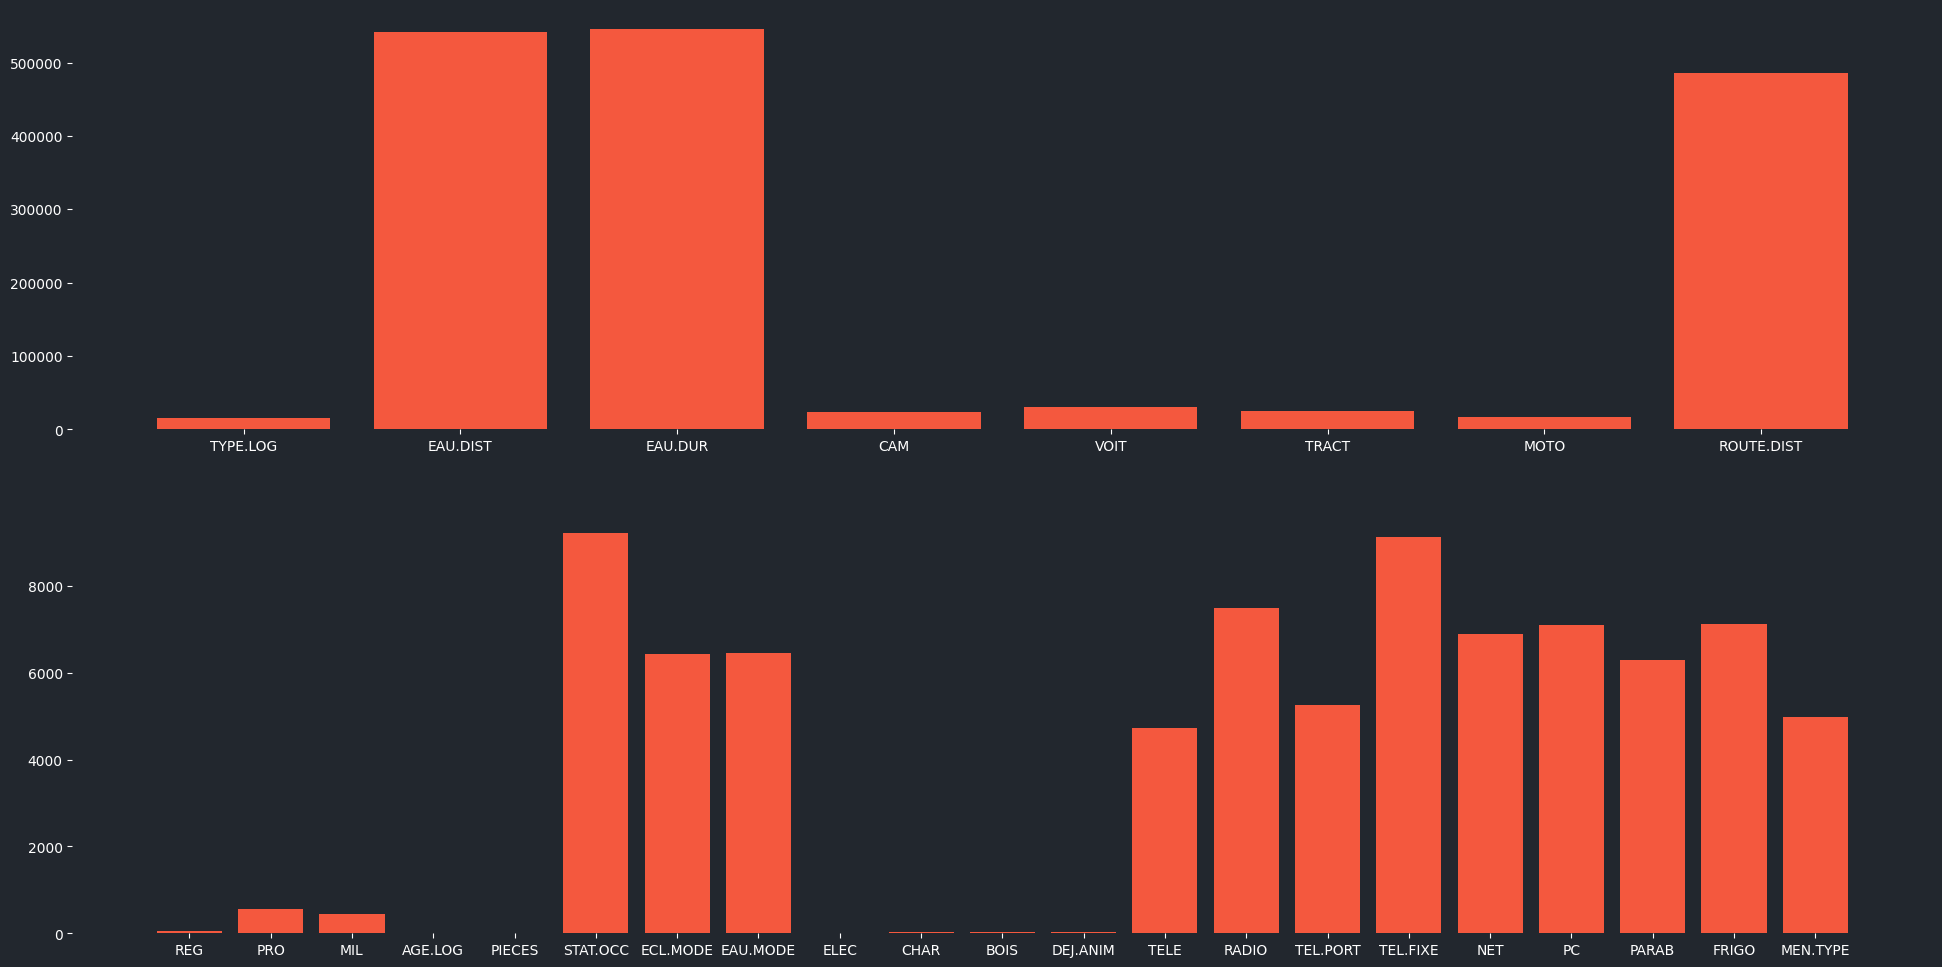

In [10]:
fig, axes = plt.subplots(2, 1, figsize = (24, 12), facecolor = '#22272E')

nulls = RGPH.isnull().sum()
nulls = nulls[nulls > 0]
limit = 10000

axes[0].bar(nulls[nulls > limit].index, nulls[nulls > limit], color = '#F4583E')
axes[0].tick_params(axis = 'x', colors = 'white')
axes[0].tick_params(axis = 'y', colors = 'white')
axes[0].set_facecolor('#22272E')
for spine in axes[0].spines.values() : spine.set_visible(False)

axes[1].bar(nulls[nulls < limit].index, nulls[nulls < limit], color = '#F4583E')
axes[1].tick_params(axis = 'x', colors = 'white')
axes[1].tick_params(axis = 'y', colors = 'white')
axes[1].set_facecolor('#22272E')
for spine in axes[1].spines.values() : spine.set_visible(False)

plt.show()

In [11]:
MapRGPH = {column: {i[1] : (i[0] if str(i[1]).lower() != 'nan' else None) for i in enumerate(RGPH[column].unique())} for column in RGPH.columns if RGPH[column].dtype == 'category'}

if not pathlib.Path('../Assets/Maps/MapRGPH.json').exists() :
    with open('../Assets/Maps/MapRGPH.json', 'w', encoding = 'utf-8') as file :
        json.dump({column : dict(sorted(map.items(), key = lambda item: len(str(item[0])))) for column, map in MapRGPH.items()}, file, indent = 4, ensure_ascii = False)

Encoded = pd.DataFrame({column: RGPH[column].map(MapRGPH[column]) for column in MapRGPH.keys()}, dtype = 'category')
CleanRGPH = pd.DataFrame({column : (RGPH[column] if column not in Encoded.columns else Encoded[column]) for column in RGPH.columns})

TypesRGPH = {column : str(CleanRGPH[column].dtype) for column in CleanRGPH.columns}

if not pathlib.Path('../Assets/Types/TypesRGPH.json').exists() :
    with open('../Assets/Types/TypesRGPH.json', 'w', encoding = 'utf-8') as file :
        json.dump(TypesRGPH, file, indent = 4, ensure_ascii = False)

for column in CleanRGPH.columns : CleanRGPH[column] = CleanRGPH[column].astype('float64')

display(CleanRGPH, pd.DataFrame({i[0] : [i[1]] for i in TypesRGPH.items()}))

,REG,PRO,MIL,MEN.PRO,TAILLE,TYPE.LOG,MURS,TOIT,SOL,AGE.LOG,PIECES,STAT.OCC,CUIS,WC,BD,BLOC,ECL.MODE,EAU.MODE,EAU.DIST,EAU.DUR,EAUX.US,DECH,GAZ,ELEC,CHAR,BOIS,DEJ.ANIM,TELE,RADIO,TEL.PORT,TEL.FIXE,NET,PC,PARAB,FRIGO,CAM,VOIT,TRACT,MOTO,ROUTE.DIST,MEN.TYPE,PDS
0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,9.999995
1,0.0,0.0,1.0,2.0,5.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,9.999995
2,0.0,0.0,1.0,3.0,5.0,0.0,1.0,1.0,0.0,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,1.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,9.999995
3,0.0,0.0,1.0,4.0,7.0,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0,2.0,3.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,9.999995
4,0.0,0.0,1.0,5.0,5.0,2.0,2.0,2.0,0.0,3.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,9.999995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730094,NaN,NaN,1.0,494.0,18.0,2.0,2.0,3.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,0.0,3.0,2.0,0.0,0.0,4.0,2.0,2.0,0.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,16.0,3.0,9.999995
730095,NaN,NaN,0.0,510.0,16.0,0.0,1.0,1.0,2.0,1.0,6.0,0.0,1.0,0.0,1.0,0.0,0.0,4.0,NaN,NaN,0.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,NaN,0.0,0.0,NaN,3.0,9.999995
730096,NaN,NaN,0.0,523.0,16.0,NaN,1.0,1.0,2.0,1.0,3.0,2.0,1.0,0.0,1.0,0.0,0.0,4.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,3.0,9.999995
730097,NaN,NaN,0.0,533.0,12.0,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,NaN,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,9.999995


,REG,PRO,MIL,MEN.PRO,TAILLE,TYPE.LOG,MURS,TOIT,SOL,AGE.LOG,PIECES,STAT.OCC,CUIS,WC,BD,BLOC,ECL.MODE,EAU.MODE,EAU.DIST,EAU.DUR,EAUX.US,DECH,GAZ,ELEC,CHAR,BOIS,DEJ.ANIM,TELE,RADIO,TEL.PORT,TEL.FIXE,NET,PC,PARAB,FRIGO,CAM,VOIT,TRACT,MOTO,ROUTE.DIST,MEN.TYPE,PDS
0,category,category,category,float64,float64,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,category,float64


In [12]:
from lightgbm import LGBMClassifier as LGBMC, LGBMRegressor as LGBMR

import warnings
warnings.filterwarnings("ignore", category = UserWarning, module = "sklearn")

DependenciesRGPH = {
    'TYPE.LOG': ['REG', 'MIL', 'MEN.PRO', 'TAILLE', 'MEN.TYPE'],
    'ECL.MODE': ['REG', 'MIL', 'ELEC', 'TYPE.LOG'],
    'EAU.MODE': ['REG', 'MIL', 'TYPE.LOG', 'EAU.DIST'],
    'EAU.DIST': ['REG', 'MIL', 'PRO', 'TYPE.LOG'],
    'EAU.DUR': ['REG', 'MIL', 'EAU.MODE', 'EAU.DIST'],
    'TELE': ['REG', 'MIL', 'MEN.PRO', 'TAILLE', 'ELEC'],
    'RADIO': ['REG', 'MIL', 'TELE', 'ELEC'],
    'TEL.PORT': ['REG', 'MIL', 'TAILLE', 'MEN.TYPE'],
    'TEL.FIXE': ['REG', 'MIL', 'TYPE.LOG', 'NET'],
    'NET': ['REG', 'MIL', 'PC', 'TELE'],
    'PC': ['REG', 'MIL', 'NET', 'TAILLE'],
    'PARAB': ['REG', 'MIL', 'TYPE.LOG'],
    'FRIGO': ['REG', 'MIL', 'ELEC', 'MEN.PRO'],
    'CAM': ['MIL', 'REG', 'TRACT', 'VOIT'],
    'VOIT': ['MIL', 'REG', 'MEN.PRO', 'TAILLE'],
    'TRACT': ['MIL', 'REG', 'PRO'],
    'MOTO': ['MIL', 'REG', 'TAILLE'],
    'REG': ['PRO', 'MIL'],
    'PRO': ['REG', 'MIL'],
    'MIL': ['REG', 'PRO', 'TYPE.LOG'],
    'STAT.OCC': ['TYPE.LOG', 'MEN.TYPE', 'TAILLE'],
    'MEN.TYPE': ['TAILLE', 'MEN.PRO', 'STAT.OCC'],
    'ROUTE.DIST': ['REG', 'PRO', 'MIL', 'TYPE.LOG']
}

DependenciesRGPH = {key: value for key, value in sorted(DependenciesRGPH.items(), key = lambda item: CleanRGPH[item[0]].isna().sum())}
DependenciesRGPH = {target: {'features': features, 'leaves': int(len(CleanRGPH[target].unique()) ** 1.5 + 2) * 2, 'samples': max(5, int(CleanRGPH[target].notna().sum() / 2000)), 'estimators': max(50, min(500, int(CleanRGPH[target].isna().sum() / 5)))} for target, features in DependenciesRGPH.items()}

if not pathlib.Path('../Assets/Dependencies/DependenciesRGPH.json').exists() :
    with open('../Assets/Dependencies/DependenciesRGPH.json', 'w', encoding = 'utf-8') as file :
        json.dump({target : features['features'] for target, features in DependenciesRGPH.items()}, file, indent = 4, ensure_ascii = False)

ModelsRGPH = {target : (LGBMR if target in ['MEN.PRO', 'TAILLE', 'PDS'] else LGBMC)(num_leaves = parameters['leaves'], n_estimators = parameters['estimators'], min_child_samples = parameters['samples'], learning_rate = 0.05, random_state = 205, n_jobs = -1, verbose = -1) for target, parameters in DependenciesRGPH.items()}

for target, model in ModelsRGPH.items() :
    if any(CleanRGPH[target].isna()) :
        if not pathlib.Path(f'../Models/Imputers/RGPH/LGBM_{target}.joblib').exists() :
            model.fit(CleanRGPH.loc[CleanRGPH[target].notna(), DependenciesRGPH[target]['features']], CleanRGPH.loc[CleanRGPH[target].notna(), target])
            joblib.dump(model, f'../Models/Imputers/RGPH/LGBM_{target}.joblib')
        else :
            ModelsRGPH[target] = joblib.load(f'../Models/Imputers/RGPH/LGBM_{target}.joblib')
        CleanRGPH.loc[CleanRGPH[target].isna(), target] = ModelsRGPH[target].predict(CleanRGPH.loc[CleanRGPH[target].isna(), DependenciesRGPH[target]['features']])

display(CleanRGPH, pd.DataFrame(CleanRGPH.isnull().sum().to_dict(), index = [0]))

,REG,PRO,MIL,MEN.PRO,TAILLE,TYPE.LOG,MURS,TOIT,SOL,AGE.LOG,PIECES,STAT.OCC,CUIS,WC,BD,BLOC,ECL.MODE,EAU.MODE,EAU.DIST,EAU.DUR,EAUX.US,DECH,GAZ,ELEC,CHAR,BOIS,DEJ.ANIM,TELE,RADIO,TEL.PORT,TEL.FIXE,NET,PC,PARAB,FRIGO,CAM,VOIT,TRACT,MOTO,ROUTE.DIST,MEN.TYPE,PDS
0,0.0,0.000000,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.116990,0.0,9.999995
1,0.0,0.000000,1.0,2.0,5.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.000000,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.0,9.999995
2,0.0,0.000000,1.0,3.0,5.0,0.0,1.0,1.0,0.0,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,1.000000,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,2.0,9.999995
3,0.0,0.000000,1.0,4.0,7.0,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0,2.000000,3.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.000000,3.0,9.999995
4,0.0,0.000000,1.0,5.0,5.0,2.0,2.0,2.0,0.0,3.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,3.000000,1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.000000,2.0,9.999995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730094,1.0,12.167241,1.0,494.0,18.0,2.0,2.0,3.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,0.0,3.0,2.0,0.0,0.000000,4.0,2.0,2.0,0.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,16.000000,3.0,9.999995
730095,1.0,13.517176,0.0,510.0,16.0,0.0,1.0,1.0,2.0,1.0,6.0,0.0,1.0,0.0,1.0,0.0,0.0,4.0,0.0,5.975054,0.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,3.899046,3.0,9.999995
730096,1.0,13.517176,0.0,523.0,16.0,0.0,1.0,1.0,2.0,1.0,3.0,2.0,1.0,0.0,1.0,0.0,0.0,4.0,0.0,5.975054,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3.899046,3.0,9.999995
730097,1.0,13.517176,0.0,533.0,12.0,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,0.0,5.975054,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.899046,3.0,9.999995


,REG,PRO,MIL,MEN.PRO,TAILLE,TYPE.LOG,MURS,TOIT,SOL,AGE.LOG,PIECES,STAT.OCC,CUIS,WC,BD,BLOC,ECL.MODE,EAU.MODE,EAU.DIST,EAU.DUR,EAUX.US,DECH,GAZ,ELEC,CHAR,BOIS,DEJ.ANIM,TELE,RADIO,TEL.PORT,TEL.FIXE,NET,PC,PARAB,FRIGO,CAM,VOIT,TRACT,MOTO,ROUTE.DIST,MEN.TYPE,PDS
0,0,0,0,0,0,0,0,0,0,1,5,0,0,0,0,0,0,0,0,0,0,0,0,10,26,27,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
ScalersRGPH = {column : StandardScaler() for column in CleanRGPH.columns if TypesRGPH[column] == 'float64' and column != 'PDS'}
ScalersRGPH = {column : (ScalersRGPH[column], ScalersRGPH[column].fit_transform(pd.DataFrame({column : CleanRGPH[column][CleanRGPH[column].notna()].tolist()}))) for column in ScalersRGPH.keys()}

for column in ScalersRGPH.keys() :
    CleanRGPH.loc[CleanRGPH[column].notna(), column] = ScalersRGPH[column][1].flatten()
    
    if not pathlib.Path(f'../Models/Scalers/RGPH/SS_{column}.joblib').exists() :
        joblib.dump(ScalersRGPH[column][0], f'../Models/Scalers/RGPH/SS_{column}.joblib')

if not pathlib.Path('../Data/Processed/CleanRGPH.parquet').exists() :
    for column in CleanRGPH.columns :
        if any(CleanRGPH[column].isnull()) :
            match str(CleanRGPH[column].dtype) :
                case 'category' : CleanRGPH[column] = CleanRGPH[column].fillna(CleanRGPH[column].mode()[0])
                case 'float64' : CleanRGPH[column] = CleanRGPH[column].fillna(CleanRGPH[column].median())
    CleanRGPH.to_parquet('../Data/Processed/CleanRGPH.parquet')

display(CleanRGPH, pd.DataFrame({column : [CleanRGPH[column].isnull().sum() == 0] for column in CleanRGPH.columns}))

,REG,PRO,MIL,MEN.PRO,TAILLE,TYPE.LOG,MURS,TOIT,SOL,AGE.LOG,PIECES,STAT.OCC,CUIS,WC,BD,BLOC,ECL.MODE,EAU.MODE,EAU.DIST,EAU.DUR,EAUX.US,DECH,GAZ,ELEC,CHAR,BOIS,DEJ.ANIM,TELE,RADIO,TEL.PORT,TEL.FIXE,NET,PC,PARAB,FRIGO,CAM,VOIT,TRACT,MOTO,ROUTE.DIST,MEN.TYPE,PDS
0,0.0,0.000000,0.0,-0.726056,-1.090852,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.116990,0.0,9.999995
1,0.0,0.000000,1.0,-0.725987,0.179217,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.000000,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.0,9.999995
2,0.0,0.000000,1.0,-0.725918,0.179217,0.0,1.0,1.0,0.0,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,1.000000,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,2.0,9.999995
3,0.0,0.000000,1.0,-0.725849,1.025930,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0,2.000000,3.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.000000,3.0,9.999995
4,0.0,0.000000,1.0,-0.725780,0.179217,2.0,2.0,2.0,0.0,3.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,3.000000,1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.000000,2.0,9.999995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730094,1.0,12.167241,1.0,-0.692004,5.682852,2.0,2.0,3.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,0.0,3.0,2.0,0.0,0.000000,4.0,2.0,2.0,0.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,16.000000,3.0,9.999995
730095,1.0,13.517176,0.0,-0.690899,4.836139,0.0,1.0,1.0,2.0,1.0,6.0,0.0,1.0,0.0,1.0,0.0,0.0,4.0,0.0,5.975054,0.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,3.899046,3.0,9.999995
730096,1.0,13.517176,0.0,-0.690001,4.836139,0.0,1.0,1.0,2.0,1.0,3.0,2.0,1.0,0.0,1.0,0.0,0.0,4.0,0.0,5.975054,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3.899046,3.0,9.999995
730097,1.0,13.517176,0.0,-0.689310,3.142713,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,0.0,5.975054,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.899046,3.0,9.999995


,REG,PRO,MIL,MEN.PRO,TAILLE,TYPE.LOG,MURS,TOIT,SOL,AGE.LOG,PIECES,STAT.OCC,CUIS,WC,BD,BLOC,ECL.MODE,EAU.MODE,EAU.DIST,EAU.DUR,EAUX.US,DECH,GAZ,ELEC,CHAR,BOIS,DEJ.ANIM,TELE,RADIO,TEL.PORT,TEL.FIXE,NET,PC,PARAB,FRIGO,CAM,VOIT,TRACT,MOTO,ROUTE.DIST,MEN.TYPE,PDS
0,True,True,True,True,True,True,True,True,True,False,False,True,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [14]:
display(pd.read_parquet('../Data/Processed/CleanRGPH.parquet'))

,REG,PRO,MIL,MEN.PRO,TAILLE,TYPE.LOG,MURS,TOIT,SOL,AGE.LOG,PIECES,STAT.OCC,CUIS,WC,BD,BLOC,ECL.MODE,EAU.MODE,EAU.DIST,EAU.DUR,EAUX.US,DECH,GAZ,ELEC,CHAR,BOIS,DEJ.ANIM,TELE,RADIO,TEL.PORT,TEL.FIXE,NET,PC,PARAB,FRIGO,CAM,VOIT,TRACT,MOTO,ROUTE.DIST,MEN.TYPE,PDS
0,0.0,0.000000,0.0,-0.726056,-1.090852,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.116990,0.0,9.999995
1,0.0,0.000000,1.0,-0.725987,0.179217,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.000000,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.0,9.999995
2,0.0,0.000000,1.0,-0.725918,0.179217,0.0,1.0,1.0,0.0,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,1.000000,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,2.0,9.999995
3,0.0,0.000000,1.0,-0.725849,1.025930,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0,2.000000,3.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.000000,3.0,9.999995
4,0.0,0.000000,1.0,-0.725780,0.179217,2.0,2.0,2.0,0.0,3.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,3.000000,1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.000000,2.0,9.999995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730094,1.0,12.167241,1.0,-0.692004,5.682852,2.0,2.0,3.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,0.0,3.0,2.0,0.0,0.000000,4.0,2.0,2.0,0.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,16.000000,3.0,9.999995
730095,1.0,13.517176,0.0,-0.690899,4.836139,0.0,1.0,1.0,2.0,1.0,6.0,0.0,1.0,0.0,1.0,0.0,0.0,4.0,0.0,5.975054,0.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,3.899046,3.0,9.999995
730096,1.0,13.517176,0.0,-0.690001,4.836139,0.0,1.0,1.0,2.0,1.0,3.0,2.0,1.0,0.0,1.0,0.0,0.0,4.0,0.0,5.975054,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3.899046,3.0,9.999995
730097,1.0,13.517176,0.0,-0.689310,3.142713,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,0.0,5.975054,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.899046,3.0,9.999995
